# Artificial Neural Networks - MLP

**Goal:** Build an ANN model for a classification problem

**Points to note:**
* We are using Fashion MNIST dataset from Kaggle. (Link: https://www.kaggle.com/datasets/zalando-research/fashionmnist)
* For simplicity, we are using only 5000 images of the entire data.
* Neural network architecture:

1. Input layer (784 features)
2. Hidden layer(128 neurons with ReLU)
3. Hidden layer (64 neurons with ReLU)
4. Output layer (10 neurons with Softmax)


**Workflow**

**Step 1:** Create dataloader objects for train and test data

**Step 2:** Construct the training loop

**Step 3:** Evaluate model on test data

## Import essentials

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

## Load Fashion MNIST data

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("zalando-research/fashionmnist")
files = os.listdir(path)

print("Path to dataset files:", path)
print("Files: \n", files)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist
Files: 
 ['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [3]:
data = pd.read_csv(os.path.join(path, files[3]))
print(f"Total Samples: ", data.shape[0])
data.head()

Total Samples:  60000


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df = data.sample(n=5000, random_state=42)
print(f"Total Samples in df: ", df.shape[0])
print(f"Number of features: ", df.iloc[0, 1:].shape[0])
print(f"Number of classes in target: ", df['label'].nunique())
df.head()

Total Samples in df:  5000
Number of features:  784
Number of classes in target:  10


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
12628,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37730,8,0,0,0,0,0,0,0,0,0,...,187,190,196,201,209,221,218,211,102,0
39991,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8525,5,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8279,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


First column: Target (1 column)

Remaining columns: Features (784 columns)

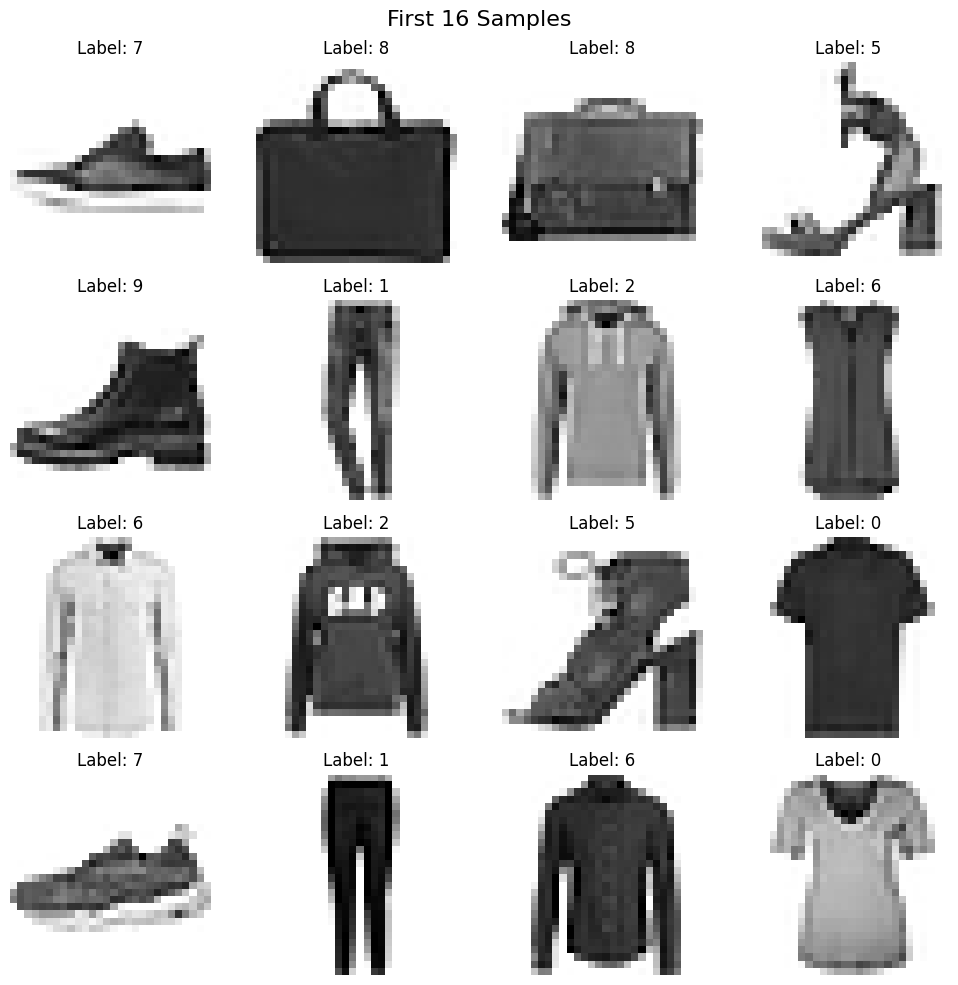

In [5]:
# images represented in pixels in a row are reshaped to 28 x 28 matrix
# the 28 x 28 matrix is then plotted using matplotlib's imshow function

fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle("First 16 Samples", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="binary")
    ax.axis("off")
    ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout()
plt.show()

## Set seed for reproducibility

In [6]:
torch.manual_seed(42)

## Split data into train and test

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scale features

In [8]:
# pixels range between 0 to 255
X_train = X_train/255.0
X_test = X_test/255.0

## Create CustomDataset class

In [9]:
class CustomDataset(Dataset):
  def __init__(self, features, target):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.target = torch.tensor(target, dtype=torch.long)

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self, index):
    return self.features[index], self.target[index]

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

## Create DataLoader

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# shuffle is set to False because the order of samples doesn't matter in evaluation

## Construct neural network model

In [11]:
class ANNModel(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, features):
    out = self.network(features)
    return out

<font color='red'>** **Important Note:** **</font> The softmax activation function is not mentioned explicitly since the cross entropy loss function automatically computes both LogSoftmax and negative log-likelihood loss together in single operation and the model outputs raw unnormalized score called logits.

## Create model instance

In [12]:
model = ANNModel(X_train.shape[1])
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 100

for epoch in range(epochs):
  loss_update = 0
  for batch_features, batch_target in train_loader:
    y_pred = model(batch_features)
    loss = loss_func(y_pred, batch_target)
    loss_update += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  epoch_loss = loss_update/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {epoch_loss}")

Epoch: 1, Loss: 1.379844078540802
Epoch: 2, Loss: 0.7875999336242676
Epoch: 3, Loss: 0.6450970413684844
Epoch: 4, Loss: 0.5797389582395553
Epoch: 5, Loss: 0.5306596257686615
Epoch: 6, Loss: 0.4863954235315323
Epoch: 7, Loss: 0.4541744738817215
Epoch: 8, Loss: 0.4312578047513962
Epoch: 9, Loss: 0.40937579941749574
Epoch: 10, Loss: 0.3991086025238037
Epoch: 11, Loss: 0.3847713485956192
Epoch: 12, Loss: 0.3636494418382645
Epoch: 13, Loss: 0.33724849331378937
Epoch: 14, Loss: 0.33108548069000243
Epoch: 15, Loss: 0.3251651494503021
Epoch: 16, Loss: 0.3157238891124725
Epoch: 17, Loss: 0.3034108659625053
Epoch: 18, Loss: 0.2961869710087776
Epoch: 19, Loss: 0.27955162471532824
Epoch: 20, Loss: 0.27787344908714295
Epoch: 21, Loss: 0.2557493271231651
Epoch: 22, Loss: 0.255690083861351
Epoch: 23, Loss: 0.24579713290929794
Epoch: 24, Loss: 0.24098690029978753
Epoch: 25, Loss: 0.24158096632361412
Epoch: 26, Loss: 0.22436513522267343
Epoch: 27, Loss: 0.21597000920772552
Epoch: 28, Loss: 0.2306060903

## Model evaluation

In [13]:
model.eval()

ANNModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [14]:
# initialize number of samples being evaluated
total_pred = 0

# initialize number of samples with correct prediction
correct_pred = 0

with torch.no_grad():
  for batch_features, batch_target in test_loader:

    # get predictions
    y_pred_t = model(batch_features)

    # get the maximum probability value and
    # its corresponding label (index of y_pred_t tensor)
    _, predicted = torch.max(y_pred_t, 1)

    # keep count of number of samples being evaluated
    total_pred += batch_target.shape[0]

    # keep count of number of samples with correct prediction
    correct_pred += (predicted == batch_target).sum().item()

  print('Correct predictions: ',correct_pred, '|Total predictions: ', total_pred)
  # compute accuracy across all samples
  print('Accuracy: ', correct_pred/total_pred)

Correct predictions:  834 |Total predictions:  1000
Accuracy:  0.834


**Ways to improve accuracy:**

* Using entire dataset on GPU
* Using different optimizers
* Adjusting learning rate
* Adjusting number of epochs
* Trying different weight initialization
* Using dropouts
* Using batch normalization
* Experimenting with model architecture